# 01 - Data Understanding
**Goal:** Load the Stack Overflow Developer Survey 2025, understand its structure, and inspect the salary column before any cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings so wide tables are not truncated
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

# Paths (the notebook lives in /notebooks, so data is one level up)
RAW_DIR = Path("../data/raw")
RESULTS_PATH = RAW_DIR / "results.csv"
SCHEMA_PATH = RAW_DIR / "schema.csv"

# Fail early with a clear message if a file is missing
assert RESULTS_PATH.exists(), f"File not found: {RESULTS_PATH.resolve()}"
assert SCHEMA_PATH.exists(), f"File not found: {SCHEMA_PATH.resolve()}"
print("Both data files found.")

Both data files found.


In [2]:
# Load survey responses and the schema (question descriptions)
df = pd.read_csv(RESULTS_PATH, low_memory=False)
schema = pd.read_csv(SCHEMA_PATH)

print(f"Rows (respondents): {df.shape[0]:,}")
print(f"Columns (questions): {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

df.head(3)

Rows (respondents): 49,191
Columns (questions): 172
Memory usage: 375.2 MB


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,...,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning new coding techniques or programming language","Online Courses or Certification (includes all media types);Other online resources (e.g. standard search, forum, onli...","Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantial addition to the tech stack",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,4.0,9.0,5.0,10.0,12.0,11.0,2.0,...,1.0,NaN,6.0,2.0,3.0,7.0,8.0,9.0,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search for answers,Project planning;Deployment and monitoring;Learning new concepts or technologies,Documenting code;Debugging or fixing code;Testing code;Committing and reviewing code;Predictive analytics;Generating...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infrequently",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI agents have reduced the time spent on specific development tasks.,AI agents have helped me automate repetitive tasks.;AI agents have improved the quality of my code.;AI agents have a...,NaN,NaN,NaN,I am concerned about the accuracy of the information provided by AI agents.;It takes significant time and effort to ...,Integrating AI agents with my existing tools and workflows can be difficult.;My company's IT and/or InfoSec teams ha...,The cost of using certain AI agent platforms is a barrier.;I have concerns about the security and privacy of data wh...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning new coding techniques or programming language","Online Courses or Certification (includes all media types);Other online res

In [3]:
print("Schema columns:", schema.columns.tolist())

def explain(col):
    """Return the original survey question for a given column name."""
    name_col = "qname" if "qname" in schema.columns else schema.columns[0]
    text_col = "question" if "question" in schema.columns else schema.columns[1]
    row = schema[schema[name_col] == col]
    if row.empty:
        return f"{col}: not found in schema"
    return f"{col}: {row.iloc[0][text_col]}"

# Columns we expect to use later in the analysis
candidate_cols = [
    "ConvertedCompYearly", "CompTotal", "Currency", "Country",
    "YearsCodePro", "WorkExp", "DevType", "EdLevel", "Employment",
    "RemoteWork", "OrgSize", "Age", "LanguageHaveWorkedWith",
]

for c in candidate_cols:
    if c in df.columns:
        print("[OK]", explain(c), "\n")
    else:
        print("[MISSING]", c, "- not present in this survey year\n")

Schema columns: ['qid', 'qname', 'question', 'type', 'sub', 'sq_id']
[OK] ConvertedCompYearly: not found in schema 

[OK] CompTotal: What is your current total <b>annual</b> compensation (salary, bonuses, and perks, before taxes and deductions) in terms of your day-to-day currency?  Please enter a whole number in the box below, without any punctuation.  If you are paid hourly, please estimate an equivalent yearly salary. If you prefer not to answer, please leave the box empty.  

[OK] Currency: Which currency do you use day-to-day? If your answer is complicated, please pick the one you're most comfortable estimating in. 

[OK] Country: Where do you live? 

[MISSING] YearsCodePro - not present in this survey year

[OK] WorkExp: How many years of professional work experience do you have? Please round to the nearest whole number, excluding any decimal points.  If your answer is '0', please leave blank. 

[OK] DevType: Which of the following describes your current job or the job you had fo

In [4]:
# One row per column: dtype, number of unique values, and % missing
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing_%": (df.isna().mean() * 100).round(1),
}).sort_values("missing_%", ascending=False)

overview.head(25)

,dtype,n_unique,missing_%
AIAgentObsWrite,str,195,99.5
SOTagsWant Entry,str,323,99.1
SOTagsHaveEntry,str,347,99.1
AIModelsWantEntry,str,299,99.0
AIAgentOrchWrite,str,332,99.0
JobSatPoints_15_TEXT,str,571,98.7
AIAgentKnowWrite,str,561,98.4
AIModelsHaveEntry,str,459,98.4
SO_Actions_15_TEXT,str,764,98.3
AIAgentExtWrite,str,421,98.3


Respondents with a reported salary: 23,947 of 49,191 (48.7%)
count       23947.0
mean       101762.0
std        461757.0
min             1.0
1%             65.0
25%         38171.0
50%         75320.0
75%        120596.0
99%        440856.0
max      50000000.0
Name: ConvertedCompYearly, dtype: float64


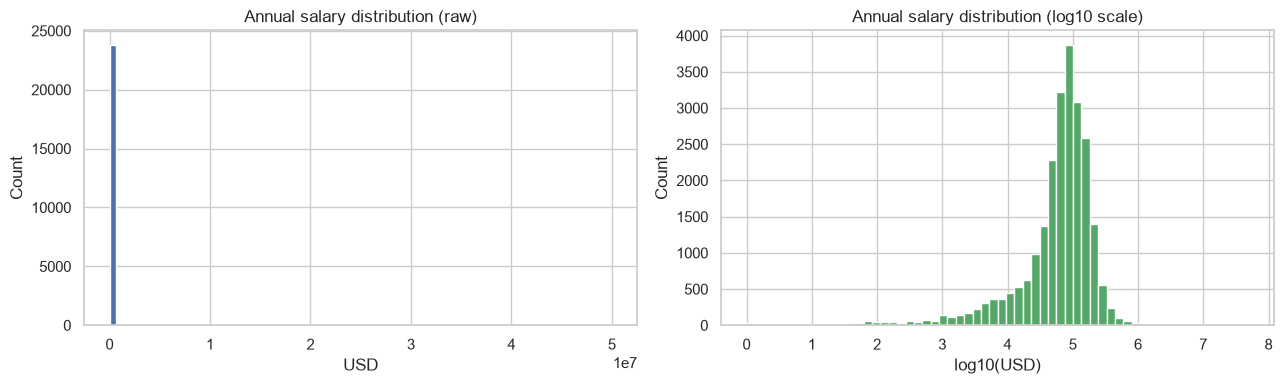

In [5]:
target = "ConvertedCompYearly"   # Annual compensation converted to USD

if target in df.columns:
    salary = df[target]

    # How many respondents actually reported a salary?
    print(f"Respondents with a reported salary: {salary.notna().sum():,} "
          f"of {len(df):,} ({salary.notna().mean() * 100:.1f}%)")
    print(salary.describe(percentiles=[.01, .25, .5, .75, .99]).round(0))

    # The log scale requires strictly positive values
    positive = salary.dropna()
    positive = positive[positive > 0]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(salary.dropna(), bins=80, color="#4C72B0")
    axes[0].set_title("Annual salary distribution (raw)")
    axes[0].set_xlabel("USD")
    axes[0].set_ylabel("Count")

    axes[1].hist(np.log10(positive), bins=60, color="#55A868")
    axes[1].set_title("Annual salary distribution (log10 scale)")
    axes[1].set_xlabel("log10(USD)")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{target}' not found. Compensation-related columns:")
    print([c for c in df.columns if "Comp" in c])

In [6]:
if "Country" in df.columns and target in df.columns:
    top_countries = (
        df.dropna(subset=[target])
          .groupby("Country")[target]
          .agg(n="count", median="median")
          .sort_values("n", ascending=False)
          .head(10)
    )
    display(top_countries)

,n,median
Country,,
United States of America,5243,150000.0
Germany,2141,81210.0
United Kingdom of Great Britain and Northern Ireland,1486,94618.0
India,1096,17029.0
France,1027,63228.0
Canada,915,87550.0
Ukraine,709,25021.0
Brazil,639,27306.0
Netherlands,619,81210.0
